In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
mainfolder = '/content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

## DATA

##### Aux functions

In [ ]:
def load_jets_rest(path):
    """
    Reads the file jets_rest.dat and returns a list of events,
    each event is a list with the (pt, eta, phi) of each jet
    """
    events = []

    with open(path, 'r') as f:
        for line in f:
            if not line.strip():
                continue  # skip empty lines

            parts = line.strip().split()
            n_jets = int(parts[0])
            jets = []

            for i in range(n_jets):
                base = 1 + i * 3
                pt = float(parts[base])
                eta = float(parts[base + 1])
                phi = float(parts[base + 2])
                jets.append((pt, eta, phi))

            events.append(jets)

    return events

In [ ]:
# -------------------------
# Function to load the data specifing type of LQ and mass, stored in dictionary
# dic: 'variables', 'fid_xsec', 'n_events'
# -------------------------
def load_LQ_data(lq_type, mass, variables):
    if lq_type == 'SLQ':
        folder = base_folder_SLQ.format(mass)
    elif lq_type == 'VLQ':
        folder = base_folder_VLQ.format(mass)
    elif lq_type == 'VLQ-YM':
        folder = base_folder_VLQ_YM.format(mass)
    else:
        raise ValueError('lq_type debe ser SLQ o VLQ')

    data = {}
    for var in variables:
        path = os.path.join(folder, f'{var}.dat')
        if var == 'jets_rest':
            data[var] = load_jets_rest(path)
        else:
            try:
                data[var] = np.loadtxt(path, delimiter=' ')
            except:
                data[var] = None

    data['n_events'] = len(data['b1']) if data['b1'] is not None else 0
    return data

In [ ]:
# -------------------------
# Data folders
# -------------------------
base_folder_SLQ = mainfolder + '../DATA-wjets/signals/dats-SLQ-{}GeV/'
base_folder_VLQ = mainfolder + '../DATA-wjets/signals/dats-VLQ-{}GeV/'
base_folder_VLQ_YM = mainfolder + '../DATA-wjets/signals/dats-VLQ-YM-{}GeV/'


# -------------------------
# Variables
# -------------------------
variables = ['b1', 'b2', 'tau', 'MET', 'hadinfo', 'jets_rest']

In [ ]:
# -------------------------
# LOAD the LQs
# -------------------------

masses_SLQ = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]

SLQ_data = {}

for m in masses_SLQ:
    SLQ_data[m] = load_LQ_data('SLQ', m, variables)



masses_VLQ = [1200, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

VLQ_data = {}

for m in masses_VLQ:
    VLQ_data[m] = load_LQ_data('VLQ', m, variables)



masses_VLQ_YM = [1200, 1800, 2000]

VLQ_YM_data = {}

for m in masses_VLQ_YM:
    VLQ_YM_data[m] = load_LQ_data('VLQ-YM', m, variables)

# -------------------------
# Example
# -------------------------
for m_it in masses_SLQ:
    print(f"# eventos SLQ {m_it} GeV:", SLQ_data[m_it]['n_events'])

print(" ")
for m_it in masses_VLQ:
    print(f"# eventos VLQ {m_it} GeV:", VLQ_data[m_it]['n_events'])

print(" ")
for m_it in masses_VLQ_YM:
    print(f"# eventos VLQ-YM {m_it} GeV:", VLQ_YM_data[m_it]['n_events'])

# eventos SLQ 1000 GeV: 267452
# eventos SLQ 1200 GeV: 534247
# eventos SLQ 1300 GeV: 196510
# eventos SLQ 1400 GeV: 506381
# eventos SLQ 1500 GeV: 185940
# eventos SLQ 1600 GeV: 481827
# eventos SLQ 1700 GeV: 173573
# eventos SLQ 1800 GeV: 301687
# eventos SLQ 1900 GeV: 64690
# eventos SLQ 2000 GeV: 156921
# eventos SLQ 2200 GeV: 145784
 
# eventos VLQ 1200 GeV: 285547
# eventos VLQ 1400 GeV: 139696
# eventos VLQ 1600 GeV: 134774
# eventos VLQ 1700 GeV: 192819
# eventos VLQ 1800 GeV: 127670
# eventos VLQ 1900 GeV: 75898
# eventos VLQ 2000 GeV: 184097
# eventos VLQ 2100 GeV: 72762
# eventos VLQ 2200 GeV: 232166
# eventos VLQ 2300 GeV: 64705
 
# eventos VLQ-YM 1200 GeV: 261538
# eventos VLQ-YM 1800 GeV: 114329
# eventos VLQ-YM 2000 GeV: 70280


In [ ]:
masses_SLQ = [1365]

SLQ_data = {}

for m in masses_SLQ:
    SLQ_data[m] = load_LQ_data('SLQ', m, variables)

for m_it in masses_SLQ:
    print(f"# eventos SLQ {m_it} GeV:", SLQ_data[m_it]['n_events'])


# eventos SLQ 1365 GeV: 23327


In [ ]:
masses_SLQ = [1100]

SLQ_data = {}

for m in masses_SLQ:
    SLQ_data[m] = load_LQ_data('SLQ', m, variables)

for m_it in masses_SLQ:
    print(f"# eventos SLQ {m_it} GeV:", SLQ_data[m_it]['n_events'])


# eventos SLQ 1100 GeV: 271062


In [ ]:
masses_VLQ = [1850]

VLQ_data = {}

for m in masses_VLQ:
    VLQ_data[m] = load_LQ_data('VLQ', m, variables)

for m_it in masses_VLQ:
    print(f"# eventos VLQ {m_it} GeV:", VLQ_data[m_it]['n_events'])


# eventos VLQ 1850 GeV: 20436


In [ ]:
masses_VLQ = [1500]

VLQ_data = {}

for m in masses_VLQ:
    VLQ_data[m] = load_LQ_data('VLQ', m, variables)

for m_it in masses_VLQ:
    print(f"# eventos VLQ {m_it} GeV:", VLQ_data[m_it]['n_events'])


# eventos VLQ 1500 GeV: 293700


In [ ]:
# -------------------------
# Function to load the background, stored in dictionary
# dic: 'variables', 'fid_xsec', 'n_events'
# -------------------------
def load_background(name, info):
    folder = info['folder']

    data = {}
    for var in variables:
        path = os.path.join(folder, f'{var}.dat')
        if var == 'jets_rest':
            data[var] = load_jets_rest(path)
        else:
            try:
                data[var] = np.loadtxt(path, delimiter=' ')
            except:
                data[var] = None

    data['n_events'] = len(data['b1']) if data['b1'] is not None else 0

    return data

In [ ]:
# -------------------------
# LOAD the backgrounds
# -------------------------
backgrounds = {
    'tt': {'folder': mainfolder + '../DATA-wjets/backgrounds/dats-tt/'},
    'singletP1': {'folder': mainfolder + '../DATA-wjets/backgrounds/dats-singletP1/'},
    'singletP2': {'folder': mainfolder + '../DATA-wjets/backgrounds/dats-singlet-comp/'},
    'Wbbjets': {'folder': mainfolder + '../DATA-wjets/backgrounds/dats-Wbbjets/'},
    'ttW': {'folder': mainfolder + '../DATA-wjets/backgrounds/dats-ttW/'},
    'ttZ': {'folder': mainfolder + '../DATA-wjets/backgrounds/dats-ttZ/'},
    'ttH': {'folder': mainfolder + '../DATA-wjets/backgrounds/dats-ttH/'}
}

SM_data = {}

for name, info in backgrounds.items():
    SM_data[name] = load_background(name, info)
    print(f"# events {name}: {SM_data[name]['n_events']}")

# events tt: 826022
# events singletP1: 179677
# events singletP2: 94219
# events Wbbjets: 162448
# events ttW: 141919
# events ttZ: 16178
# events ttH: 12068


### Plot

In [ ]:
def plot_variable(var_name, SLQ_data, VLQ_data, SM_data,
                  masses_SLQ, masses_VLQ,
                  bins=25, range=[20,2500], logy=True):

    plt.figure(figsize=(6,5))

    # --- Señal SLQ ---
    colors_SLQ = ['red', 'pink', 'orange', 'purple']  # ajustar según # de masas
    for i, m in enumerate(masses_SLQ):
        data = SLQ_data[m][var_name]
        plt.hist(data[:,0], bins=bins, lw=2, range=range, density=True,
                 edgecolor=colors_SLQ[i], histtype='step', label=f'SLQ {m} GeV')

    # --- Señal VLQ ---
    colors_VLQ = ['lime', 'dodgerblue', 'cyan', 'magenta']  # ajustar según # de masas
    for i, m in enumerate(masses_VLQ):
        data = VLQ_data[m][var_name]
        plt.hist(data[:,0], bins=bins, lw=2, range=range, density=True,
                 edgecolor=colors_VLQ[i], histtype='step', label=f'VLQ {m} GeV')

    # --- Background stacked ---
    # se combinan todos los backgrounds en un solo histograma apilado
    bg_data_list = [
        SM_data['tt'][var_name],
        np.concatenate([SM_data['singletP1'][var_name], SM_data['singletP2'][var_name]]),
        SM_data['Wbbjets'][var_name],
        np.concatenate([SM_data['ttW'][var_name], SM_data['ttZ'][var_name], SM_data['ttH'][var_name]])
    ]

    bg_colors = ['blue','green','magenta','black']
    plt.hist([d[:,0] for d in bg_data_list], bins=bins, lw=2, range=range, density=True,
             stacked=True, color=bg_colors, label=['tt','single t','W+j','tt/fake'])

    # --- Configuración del plot ---
    plt.grid()
    plt.xlabel(f"{var_name} [GeV]", fontsize=14)
    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(range)

    if logy:
        plt.yscale('log')
        plt.ylim(1e-7,1e-2)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=10)
    plt.show()

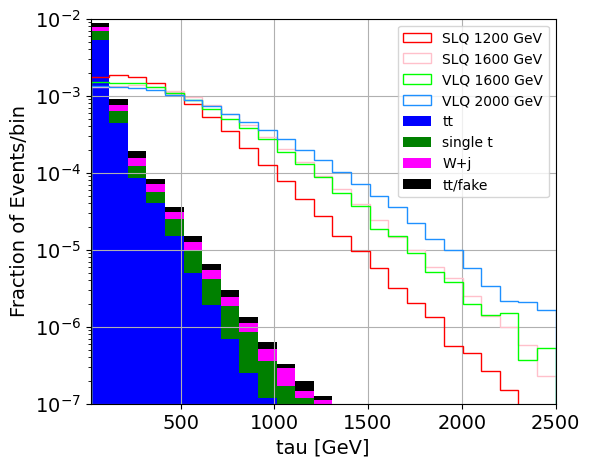

In [ ]:
# Ejemplo: plot pT del tau
plot_variable('tau', SLQ_data, VLQ_data, SM_data,
              masses_SLQ=[1200,1600],
              masses_VLQ=[1600,2000],
              bins=25, range=[20,2500])

#### JET INFO

In [ ]:
# TO EXTRACT THE JET INFO

def get_jet_activity(events):
    """
    Returns (n_jets, suma_pt) for each event.
    """
    jet_act = []
    for jets in events:
        n = len(jets)
        pt_sum = sum(j[0] for j in jets) if n > 0 else 0.0
        jet_act.append((n, pt_sum))
    return np.array(jet_act)


def get_jet_info(events, jet_index):
    """
    Returs (pt, eta, phi) for each event considering the jet with number 'jet_index'
    If the event has no 'jet_index' jet, completes with (0.0, 0.0, 0.0)
    """
    jet_info = []
    for jets in events:
        if len(jets) > jet_index:
            jet_info.append(jets[jet_index])
        else:
            jet_info.append((0.0, 0.0, 0.0))
    return np.array(jet_info)

In [ ]:
# ---------------------------
# VLQ-YM data
# ---------------------------

for mass in masses_VLQ_YM:

    VLQ_YM_data[mass]['jet_act'] = get_jet_activity(VLQ_YM_data[mass]['jets_rest'])
    VLQ_YM_data[mass]['jet1'] = get_jet_info(VLQ_YM_data[mass]['jets_rest'], 0)
    VLQ_YM_data[mass]['jet2'] = get_jet_info(VLQ_YM_data[mass]['jets_rest'], 1)

    del VLQ_YM_data[mass]['jets_rest']

In [ ]:
# ---------------------------
# VLQ data
# ---------------------------

for mass in masses_VLQ:

    VLQ_data[mass]['jet_act'] = get_jet_activity(VLQ_data[mass]['jets_rest'])
    VLQ_data[mass]['jet1'] = get_jet_info(VLQ_data[mass]['jets_rest'], 0)
    VLQ_data[mass]['jet2'] = get_jet_info(VLQ_data[mass]['jets_rest'], 1)

    del VLQ_data[mass]['jets_rest']

In [ ]:
# ---------------------------
# SLQ data
# ---------------------------

for mass in masses_SLQ:
    SLQ_data[mass]['jet_act'] = get_jet_activity(SLQ_data[mass]['jets_rest'])
    SLQ_data[mass]['jet1'] = get_jet_info(SLQ_data[mass]['jets_rest'], 0)
    SLQ_data[mass]['jet2'] = get_jet_info(SLQ_data[mass]['jets_rest'], 1)

    del SLQ_data[mass]['jets_rest']

In [ ]:
# ---------------------------
# Background:
# ---------------------------

channels = list(SM_data.keys())

for ch in channels:
    SM_data[ch]['jet_act'] = get_jet_activity(SM_data[ch]['jets_rest'])
    SM_data[ch]['jet1'] = get_jet_info(SM_data[ch]['jets_rest'], 0)
    SM_data[ch]['jet2'] = get_jet_info(SM_data[ch]['jets_rest'], 1)

    del SM_data[ch]['jets_rest']

# HIGH-LEVEL FEATURES

In [ ]:
def delta_phi(p1, p2):
    """ phi diff in [-π, π]."""

    phi1 = p1[:,2]
    phi2 = p2[:,2]

    dphi = phi1 - phi2
    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
    return dphi

def delta_R(p1, p2):
    """ΔR given (eta, phi)."""

    eta1 = p1[:,1]
    phi1 = p1[:,2]

    eta2 = p2[:,1]
    phi2 = p2[:,2]

    d_eta = eta1 - eta2
    d_phi = delta_phi(p1, p2)
    return np.sqrt(d_eta**2 + d_phi**2)


def inv_mass(p1, p2):
    """invariant mass (massless particles approx)."""
    pt1 = p1[:,0]
    eta1 = p1[:,1]
    phi1 = p1[:,2]

    pt2 = p2[:,0]
    eta2 = p2[:,1]
    phi2 = p2[:,2]


    delta_eta = eta1 - eta2
    delta_phi = np.mod(phi1 - phi2 + np.pi, 2 * np.pi) - np.pi  # [-π, π]

    cosh_delta_eta = np.cosh(delta_eta)
    cos_delta_phi = np.cos(delta_phi)

    m2 = 2 * pt1 * pt2 * (cosh_delta_eta - cos_delta_phi)
    m2 = np.maximum(m2, 0.0)  # avoid negative roots
    return np.sqrt(m2)


def trans_mass(p1, p2):
    """transverse mass between two objects (pt, phi)."""
    pt1 = p1[:,0]
    phi1 = p1[:,2]

    pt2 = p2[:,0]
    phi2 = p2[:,2]

    delta_phi = np.mod(phi1 - phi2 + np.pi, 2 * np.pi) - np.pi  # [-π, π]
    return np.sqrt(2 * pt1 * pt2 * (1 - np.cos(delta_phi)))


def sT(tau, b1, b2, jet1, jet2):
    """
    the scalar sum of the transverse momenta of the tau lepton and the two leading jets.
    """
    tau_pt = tau[:, 0]

    # Stack pt of b1, b2, jet1, jet2 => shape (N, 4)
    others_pt = np.stack([b1[:, 0], b2[:, 0], jet1[:, 0], jet2[:, 0]], axis=1)

    # Obtain the 2 higher pTs per row
    top2_pt = np.partition(others_pt, -2, axis=1)[:, -2:]

    # Sum the pTs: tau_pt + top2_pt.sum(axis=1)
    total_pt = tau_pt + np.sum(top2_pt, axis=1)

    return total_pt


def pT12(p1, p2):
    """
    transverse momenta of the p1 p2 system
    """
    px1 = p1[:, 0] * np.cos(p1[:, 1])
    px2 = p2[:, 0] * np.cos(p2[:, 1])

    px12 = px1 + px2

    py1 = p1[:, 0] * np.sin(p1[:, 1])
    py2 = p2[:, 0] * np.sin(p2[:, 1])

    py12 = py1 + py2

    return np.sqrt( px12**2 + py12**2 )


def costhetaCS(p1, p2):
    """
    cosine of the angle between p1 and p2 in Collins-Soper frame
    """
    dR12 = p1[:,2] - p2[:,2]
    p_T_12 = pT12(p1, p2)
    m12 = inv_mass(p1, p2)

    return ( np.sinh(dR12) / np.sqrt( 1 + (p_T_12/m12)**2 ) ) * (2 * p1[:,0] * p2[:,0] / (m12**2) )




In [ ]:
def compute_high_level_features(features):
    """
    Compute deltaR, deltaPhi, invariant masses, transverse masses, sT, mTb1b2, mTj1j2
    for a dictionary containing 'b1', 'b2', 'tau', 'jet1', 'jet2', 'MET'.
    Returns a dictionary with the new features.
    """
    f = {}  # new features

    # --- delta R ---
    f['dR_tau_b1'] = delta_R(features['tau'], features['b1'])
    f['dR_tau_b2'] = delta_R(features['tau'], features['b2'])
    f['dR_b1_b2'] = delta_R(features['b1'], features['b2'])

    f['dR_jet1_b1'] = delta_R(features['jet1'], features['b1'])
    f['dR_jet1_b2'] = delta_R(features['jet1'], features['b2'])
    f['dR_jet1_tau'] = delta_R(features['jet1'], features['tau'])

    f['dR_jet2_b1'] = delta_R(features['jet2'], features['b1'])
    f['dR_jet2_b2'] = delta_R(features['jet2'], features['b2'])
    f['dR_jet2_tau'] = delta_R(features['jet2'], features['tau'])

    f['dR_jet1_jet2'] = delta_R(features['jet1'], features['jet2'])

    # --- delta phi ---
    f['dphi_tau_b1'] = delta_phi(features['tau'], features['b1'])
    f['dphi_tau_b2'] = delta_phi(features['tau'], features['b2'])
    f['dphi_b1_b2'] = delta_phi(features['b1'], features['b2'])

    f['dphi_MET_b1'] = delta_phi(features['MET'], features['b1'])
    f['dphi_MET_b2'] = delta_phi(features['MET'], features['b2'])
    f['dphi_MET_tau'] = delta_phi(features['MET'], features['tau'])
    f['dphi_MET_jet1'] = delta_phi(features['MET'], features['jet1'])
    f['dphi_MET_jet2'] = delta_phi(features['MET'], features['jet2'])

    # --- invariant masses ---
    f['m_tau_b1'] = inv_mass(features['tau'], features['b1'])
    f['m_tau_b2'] = inv_mass(features['tau'], features['b2'])
    f['m_b1_b2'] = inv_mass(features['b1'], features['b2'])

    f['m_jet1_b1'] = inv_mass(features['jet1'], features['b1'])
    f['m_jet1_b2'] = inv_mass(features['jet1'], features['b2'])
    f['m_jet1_tau'] = inv_mass(features['jet1'], features['tau'])

    f['m_jet2_b1'] = inv_mass(features['jet2'], features['b1'])
    f['m_jet2_b2'] = inv_mass(features['jet2'], features['b2'])
    f['m_jet2_tau'] = inv_mass(features['jet2'], features['tau'])

    f['m_jet1_jet2'] = inv_mass(features['jet1'], features['jet2'])

    # --- transverse masses ---
    f['mT_MET_b1'] = trans_mass(features['MET'], features['b1'])
    f['mT_MET_b2'] = trans_mass(features['MET'], features['b2'])
    f['mT_MET_tau'] = trans_mass(features['MET'], features['tau'])
    f['mT_MET_jet1'] = trans_mass(features['MET'], features['jet1'])
    f['mT_MET_jet2'] = trans_mass(features['MET'], features['jet2'])

    f['mTb1b2'] = f['mT_MET_b1'] + f['mT_MET_b2']
    f['mTj1j2'] = f['mT_MET_jet1'] + f['mT_MET_jet2']

    # --- sT ---
    f['sT'] = sT(features['tau'], features['b1'], features['b2'], features['jet1'], features['jet2'])

    return f

In [ ]:
# --- Apply to all SLQ ---
for mass in SLQ_data:
    SLQ_data[mass].update(compute_high_level_features(SLQ_data[mass]))

In [ ]:
# --- Apply to all VLQ ---
for mass in VLQ_data:
    VLQ_data[mass].update(compute_high_level_features(VLQ_data[mass]))

In [ ]:
# --- Apply to all VLQ-YM ---
for mass in VLQ_YM_data:
    VLQ_YM_data[mass].update(compute_high_level_features(VLQ_YM_data[mass]))

In [ ]:
# --- Apply to the background ---
for ch in SM_data:
    SM_data[ch].update(compute_high_level_features(SM_data[ch]))

In [ ]:
SM_data['tt']['sT']

array([369.81, 527.92, 414.95, ..., 714.74, 848.94, 556.56])

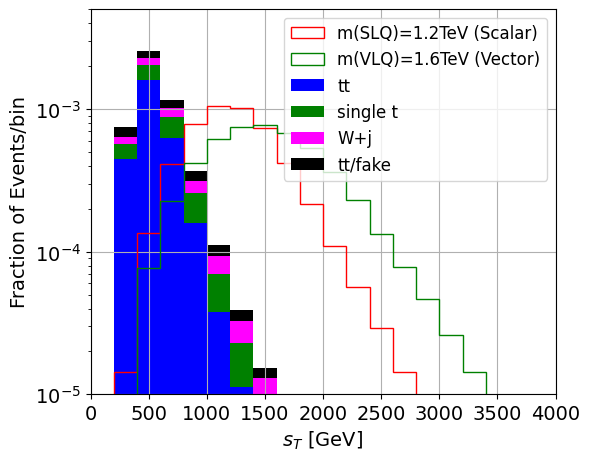

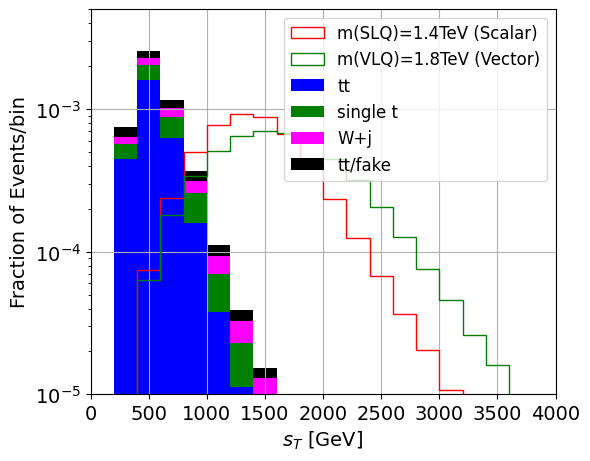

In [ ]:
def plot_feat(slq_mass, vlq_mass, feat_SLQ, feat_VLQ, feat_SM, slq_label=None, vlq_label=None):
    plt.figure(figsize=(6,5))

    plt.hist(feat_SLQ, bins=25, lw=2, range=[0,5000], density=True,
             edgecolor='red', histtype='step', label=slq_label)

    plt.hist(feat_VLQ, bins=25, lw=2, range=[0,5000], density=True,
             edgecolor='green', histtype='step', label=vlq_label)

    # plt.hist(feat_SM, bins=25, lw=2, range=[0,5000], density=True, stacked=True, color=["blue"], label='SM')
    # # --- Background stacked ---
    # se combinan todos los backgrounds en un solo histograma apilado
    bg_data_list = [
        SM_data['tt'][feat_SM],
        np.concatenate([SM_data['singletP1'][feat_SM], SM_data['singletP2'][feat_SM]]),
        SM_data['Wbbjets'][feat_SM],
        np.concatenate([SM_data['ttW'][feat_SM], SM_data['ttZ'][feat_SM], SM_data['ttH'][feat_SM]])
    ]

    bg_colors = ['blue','green','magenta','black']
    plt.hist([d[:] for d in bg_data_list], bins=25, range=[0,5000], lw=2, density=True,
             stacked=True, color=bg_colors, label=['tt','single t','W+j','tt/fake'])

    plt.grid()
#     plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(0,4000)
    plt.ylim(1e-5,5e-3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.yscale('log')
    plt.legend(fontsize=12)
#     plt.show()





feat = 'sT'

plot_feat(
    1200, 1600,
    SLQ_data[1200][feat],
    VLQ_data[1600][feat],
    feat,
    slq_label=r'm(SLQ)=1.2TeV (Scalar)',
    vlq_label=r'm(VLQ)=1.6TeV (Vector)'
)
plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
plt.show()

plot_feat(
    1400, 1800,
    SLQ_data[1400][feat],
    VLQ_data[1800][feat],
    feat,
    slq_label=r'm(SLQ)=1.4TeV (Scalar)',
    vlq_label=r'm(VLQ)=1.8TeV (Vector)'
)
plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
plt.show()




# DATA FORMAT for CLASSIFIERS

In [ ]:
# Function to converts the features into a DataFrame

def features_to_df(features_dict):
    df = pd.DataFrame({
        'b1-pt': features_dict['b1'][:,0], 'b1-eta': features_dict['b1'][:,1], 'b1-phi': features_dict['b1'][:,2],
        'b2-pt': features_dict['b2'][:,0], 'b2-eta': features_dict['b2'][:,1], 'b2-phi': features_dict['b2'][:,2],
        'tau-pt': features_dict['tau'][:,0], 'tau-eta': features_dict['tau'][:,1], 'tau-phi': features_dict['tau'][:,2],
        'jet1-pt': features_dict['jet1'][:,0], 'jet1-eta': features_dict['jet1'][:,1], 'jet1-phi': features_dict['jet1'][:,2],
        'jet2-pt': features_dict['jet2'][:,0], 'jet2-eta': features_dict['jet2'][:,1], 'jet2-phi': features_dict['jet2'][:,2],
        'MET-pt': features_dict['MET'][:,0], 'MET-phi': features_dict['MET'][:,2],
        'HT-pt': features_dict['hadinfo'][:,0], 'num-jets': features_dict['hadinfo'][:,1], 'num-bjets': features_dict['hadinfo'][:,2],
        'dR-taub1': features_dict['dR_tau_b1'], 'dR-taub2': features_dict['dR_tau_b2'], 'dR-b1b2': features_dict['dR_b1_b2'],
        'dR-j1b1': features_dict['dR_jet1_b1'], 'dR-j1b2': features_dict['dR_jet1_b2'], 'dR-j1tau': features_dict['dR_jet1_tau'],
        'dR-j2b1': features_dict['dR_jet2_b1'], 'dR-j2b2': features_dict['dR_jet2_b2'], 'dR-j2tau': features_dict['dR_jet2_tau'],
        'dR-j1j2': features_dict['dR_jet1_jet2'],
        'dphi-METb1': features_dict['dphi_MET_b1'], 'dphi-METb2': features_dict['dphi_MET_b2'], 'dphi-METtau': features_dict['dphi_MET_tau'],
        'dphi-METj1': features_dict['dphi_MET_jet1'], 'dphi-METj2': features_dict['dphi_MET_jet2'],
        'm-taub1': features_dict['m_tau_b1'], 'm-taub2': features_dict['m_tau_b2'], 'm-b1b2': features_dict['m_b1_b2'],
        'm-j1b1': features_dict['m_jet1_b1'], 'm-j1b2': features_dict['m_jet1_b2'], 'm-j1tau': features_dict['m_jet1_tau'],
        'm-j2b1': features_dict['m_jet2_b1'], 'm-j2b2': features_dict['m_jet2_b2'], 'm-j2tau': features_dict['m_jet2_tau'],
        'm-j1j2': features_dict['m_jet1_jet2'],
        'mT-METb1': features_dict['mT_MET_b1'], 'mT-METb2': features_dict['mT_MET_b2'], 'mT-METtau': features_dict['mT_MET_tau'],
        'mT-METj1': features_dict['mT_MET_jet1'], 'mT-METj2': features_dict['mT_MET_jet2'],
        'mTb1b2': features_dict['mTb1b2'], 'mTj1j2': features_dict['mTj1j2'],'sT': features_dict['sT']
    })
    return df

# SAVE

In [ ]:
# --- Apply to all SLQ ---
for mass in SLQ_data:
    # Create the DataFrame
    df = features_to_df(SLQ_data[mass])

    # Save to CSV
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass) + 'GeV/df_SLQ_' + str(mass) + "GeV.csv"
    df.to_csv(filename, index=False)

    print(f"File with features saved:     {filename}")

File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-SLQ-1200GeV/df_SLQ_1200GeV.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-SLQ-1300GeV/df_SLQ_1300GeV.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-SLQ-1400GeV/df_SLQ_1400GeV.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-SLQ-1500GeV/df_SLQ_1500GeV.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-SLQ-1600GeV/df_SLQ_1600GeV.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-SLQ-1700GeV/df_SLQ_1700GeV.csv
File with featur

In [ ]:
# --- Apply to all SLQ ---
for mass in SLQ_data:
    # Create the DataFrame
    df = features_to_df(SLQ_data[mass])

    # Save to CSV
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass) + 'GeV/df_SLQ_' + str(mass) + "GeV.csv"
    df.to_csv(filename, index=False)

    print(f"File with features saved:     {filename}")

File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-SLQ-1100GeV/df_SLQ_1100GeV.csv


In [ ]:
# --- Apply to all VLQ ---
for mass in VLQ_data:
    # Create the DataFrame
    df = features_to_df(VLQ_data[mass])

    # Save to CSV
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass) + 'GeV/df_VLQ_' + str(mass) + "GeV.csv"
    df.to_csv(filename, index=False)

    print(f"File with features saved:     {filename}")

File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-VLQ-1200GeV/df_VLQ_1200GeV.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-VLQ-1400GeV/df_VLQ_1400GeV.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-VLQ-1600GeV/df_VLQ_1600GeV.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-VLQ-1700GeV/df_VLQ_1700GeV.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-VLQ-1800GeV/df_VLQ_1800GeV.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-VLQ-1900GeV/df_VLQ_1900GeV.csv
File with featur

In [ ]:
# --- Apply to all VLQ ---
for mass in VLQ_data:
    # Create the DataFrame
    df = features_to_df(VLQ_data[mass])

    # Save to CSV
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass) + 'GeV/df_VLQ_' + str(mass) + "GeV.csv"
    df.to_csv(filename, index=False)

    print(f"File with features saved:     {filename}")

File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-VLQ-1500GeV/df_VLQ_1500GeV.csv


In [ ]:
# --- Apply to all VLQ-YM ---
for mass in VLQ_YM_data:
    # Create the DataFrame
    df = features_to_df(VLQ_YM_data[mass])

    # Save to CSV
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-YM-' + str(mass) + 'GeV/df_VLQ_YM_' + str(mass) + "GeV.csv"
    df.to_csv(filename, index=False)

    print(f"File with features saved:     {filename}")

File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-VLQ-YM-1200GeV/df_VLQ_YM_1200GeV.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-VLQ-YM-1800GeV/df_VLQ_YM_1800GeV.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/signals/dats-VLQ-YM-2000GeV/df_VLQ_YM_2000GeV.csv


In [ ]:
# --- Apply to all Background ---
for ch in SM_data:
    # Create the DataFrame
    df = features_to_df(SM_data[ch])

    # Save to CSV
    if ch == 'singletP2':
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-singlet-comp/df_' + ch + ".csv"
    else:
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-' + ch + '/df_' + ch + ".csv"

    df.to_csv(filename, index=False)

    print(f"File with features saved:     {filename}")

File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/backgrounds/dats-tt/df_tt.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/backgrounds/dats-singletP1/df_singletP1.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/backgrounds/dats-singlet-comp/df_singletP2.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/backgrounds/dats-Wbbjets/df_Wbbjets.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/backgrounds/dats-ttW/df_ttW.csv
File with features saved:     /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/02-pythons2026/../DATA-wjets/backgrounds/dats-ttZ/df_ttZ.csv
File with features saved:     /content/drive/MyDrive/Tr

# LOAD

### Background

In [ ]:
CHs_selected = ["tt", "singletP1", "singletP2", "Wbbjets", "ttW", "ttZ", "ttH"]


df_B_all = {}
X_B_all = {}


output_folder = mainfolder + "../DATA/backgrounds/data_df/"

for CH_sel in CHs_selected:
    # Read the file
    if CH_sel == 'singletP2':
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-singlet-comp/df_' + CH_sel + ".csv"
    else:
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-' + CH_sel + '/df_' + CH_sel + ".csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_B_all[CH_sel] = df_temp
    X_B_all[CH_sel] = df_temp[feats_label].values

    # Print
    print(f"X_{CH_sel}.shape: {X_B_all[CH_sel].shape}")

X_tt.shape: (826022, 53)
X_singletP1.shape: (179677, 53)
X_singletP2.shape: (94219, 53)
X_Wbbjets.shape: (162448, 53)
X_ttW.shape: (141919, 53)
X_ttZ.shape: (16178, 53)
X_ttH.shape: (12068, 53)


In [ ]:
df_B_all['tt']

,b1-pt,b1-eta,b1-phi,b2-pt,b2-eta,b2-phi,tau-pt,tau-eta,tau-phi,jet1-pt,...,m-j2tau,m-j1j2,mT-METb1,mT-METb2,mT-METtau,mT-METj1,mT-METj2,mTb1b2,mTj1j2,sT
0,47.98,0.698,3.005,28.35,-0.120,-0.425,38.66,0.576,-1.968,283.17,...,0.000000,0.000000,196.799807,74.366585,70.995337,567.687315,0.000000,271.166393,567.687315,369.81
1,78.27,-1.575,-0.024,67.61,0.160,-2.776,28.19,-1.587,-2.481,381.12,...,88.691271,496.639284,293.517647,10.355391,32.807315,648.540119,208.555372,303.873037,857.095491,527.92
2,122.23,0.643,0.404,44.08,0.368,2.701,52.01,0.215,-2.505,240.71,...,270.097377,937.307048,380.239212,111.606875,7.467696,524.464007,272.197519,491.846087,796.661526,414.95
3,258.00,-1.119,-1.019,150.98,-0.837,-0.284,91.36,0.041,2.199,35.60,...,0.000000,0.000000,543.100518,411.457124,39.012633,103.444790,0.000000,954.557641,103.444790,500.34
4,139.03,1.236,-2.250,44.66,1.776,-0.328,39.25,1.564,1.084,373.71,...,426.429732,793.600460,423.146022,136.798426,22.221996,666.678536,99.939294,559.944448,766.617829,561.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
826017,71.81,0.356,-1.042,56.25,0.916,2.571,29.61,-0.125,2.281,408.14,...,30.297284,311.298829,291.072066,32.044712,51.587086,738.701906,25.518670,323.116777,764.220576,509.56
826018,156.37,1.234,-2.591,45.13,1.109,2.204,48.92,1.136,0.631,123.05,...,135.476967,70.010908,437.910520,136.575535,46.222225,361.697026,361.896444,574.486055,723.593470,328.34
826019,374.70,0.640,-2.858,99.42,-0.935,-0.458,125.31,-0.774,0.427,214.73,...,92.694026,164.785664,665.707545,53.189724,112.962486,503.441278,94.151227,718.897269,597.592505,714.74
826020,566.60,0.074,0.901,127.66,2.318,-1.901,154.68,0.599,-2.758,101.97,...,92.842336,447.307216,890.685722,118.183326,68.591537,343.715273,41.180067,1008.869048,384.895340,848.94


In [ ]:
X_B_all["ttW"].shape

(141919, 53)

### Signal SLQ

In [ ]:
masses_SLQ = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]


df_SLQ_all = {}
X_SLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_SLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass_sel) + 'GeV/df_SLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_SLQ_all[mass_sel] = df_temp
    X_SLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_SLQ_{mass_sel}GeV.shape: {X_SLQ_all[mass_sel].shape}")

X_SLQ_1200GeV.shape: (534247, 53)
X_SLQ_1300GeV.shape: (196510, 53)
X_SLQ_1400GeV.shape: (506381, 53)
X_SLQ_1500GeV.shape: (185940, 53)
X_SLQ_1600GeV.shape: (481827, 53)
X_SLQ_1700GeV.shape: (173573, 53)
X_SLQ_1800GeV.shape: (301687, 53)
X_SLQ_1900GeV.shape: (64690, 53)
X_SLQ_2000GeV.shape: (156921, 53)
X_SLQ_2200GeV.shape: (145784, 53)


In [ ]:
df_SLQ_all[1600]

,b1-pt,b1-eta,b1-phi,b2-pt,b2-eta,b2-phi,tau-pt,tau-eta,tau-phi,jet1-pt,...,m-j2tau,m-j1j2,mT-METb1,mT-METb2,mT-METtau,mT-METj1,mT-METj2,mTb1b2,mTj1j2,sT
0,715.11,-0.438,0.575,422.70,0.713,-1.952,355.97,0.048,-1.554,466.21,...,184.337419,114.936848,625.073893,979.871737,916.516503,897.363982,221.528418,1604.945630,1118.892400,1537.29
1,515.22,1.107,-0.130,27.57,-0.734,0.540,252.94,-0.769,-2.328,798.34,...,357.329338,349.292183,660.281920,209.556073,325.679522,1319.264066,639.130610,869.837993,1958.394675,1566.50
2,1153.32,0.243,-1.953,275.30,0.630,-0.111,323.77,-0.182,-0.096,506.31,...,519.788196,538.377683,1849.521620,702.475488,756.898972,149.476468,438.621350,2551.997109,588.097818,1983.40
3,328.02,0.312,-2.179,119.45,-0.785,-1.788,470.96,-1.316,0.237,134.58,...,410.099510,233.057296,750.491300,495.357614,807.459945,441.645593,484.716832,1245.848913,926.362426,933.56
4,894.46,0.419,-2.771,342.91,-0.645,0.837,568.13,-0.915,1.439,88.96,...,229.149336,157.456367,1344.169104,758.633438,1190.259051,505.235852,183.823263,2102.802542,689.059115,1805.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481822,653.53,0.514,-2.640,37.34,-0.068,0.639,351.34,0.952,0.263,306.50,...,744.139124,323.406730,1378.987121,36.431276,300.633682,939.914858,813.070746,1415.418397,1752.985604,1311.37
481823,1162.87,0.826,-2.724,35.00,-0.048,1.399,500.77,-0.488,-1.358,1064.92,...,171.860185,219.877230,1434.676531,161.404100,610.890254,724.178744,8.963359,1596.080631,733.142103,2728.56
481824,436.47,-0.533,1.350,115.92,0.847,0.624,1375.25,-0.527,-0.609,34.04,...,0.000000,0.000000,1170.465058,748.099479,2641.652034,62.974659,0.000000,1918.564538,62.974659,1927.64
481825,499.55,0.710,2.740,101.57,-2.005,1.288,464.06,-1.283,2.920,209.96,...,1072.796601,484.560820,1155.173978,372.474634,1113.814907,270.795094,44.139052,1527.648612,314.934146,1173.57


In [ ]:
X_SLQ_all[1900].shape

(64690, 53)

### Signal VLQ

In [ ]:
masses_VLQ = [1200, 1400, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]


df_VLQ_all = {}
X_VLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_VLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass_sel) + 'GeV/df_VLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_VLQ_all[mass_sel] = df_temp
    X_VLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_VLQ_{mass_sel}GeV.shape: {X_VLQ_all[mass_sel].shape}")

X_VLQ_1200GeV.shape: (285547, 53)
X_VLQ_1400GeV.shape: (139696, 53)
X_VLQ_1600GeV.shape: (134774, 53)
X_VLQ_1700GeV.shape: (192819, 53)
X_VLQ_1800GeV.shape: (127670, 53)
X_VLQ_1900GeV.shape: (75898, 53)
X_VLQ_2000GeV.shape: (184097, 53)
X_VLQ_2100GeV.shape: (72762, 53)
X_VLQ_2200GeV.shape: (232166, 53)
X_VLQ_2300GeV.shape: (64705, 53)


In [ ]:
df_VLQ_all[1600]

,b1-pt,b1-eta,b1-phi,b2-pt,b2-eta,b2-phi,tau-pt,tau-eta,tau-phi,jet1-pt,...,m-j2tau,m-j1j2,mT-METb1,mT-METb2,mT-METtau,mT-METj1,mT-METj2,mTb1b2,mTj1j2,sT
0,1461.40,-0.111,-1.720,33.21,0.554,-0.557,202.40,-0.510,0.277,341.01,...,337.136963,526.062175,2521.981712,354.661413,647.960506,616.351380,47.173418,2876.643125,663.524798,2004.81
1,635.23,0.375,-2.612,287.77,-0.360,-3.137,1290.90,0.097,0.437,132.82,...,470.360484,166.624251,82.914455,209.162502,1260.454621,241.050951,54.259344,292.076957,295.310295,2213.90
2,165.90,-0.543,-2.915,121.39,2.292,-0.475,107.83,-1.241,2.836,247.73,...,68.193560,161.998619,441.185069,17.983104,382.140903,517.293108,336.547653,459.168173,853.840760,521.46
3,262.74,-1.787,-1.319,82.01,-0.083,2.086,441.25,-1.119,-2.481,528.89,...,1593.305794,935.106915,811.358783,120.700539,957.489185,1113.159090,53.256951,932.059322,1166.416041,1433.41
4,487.05,0.689,2.757,123.66,-0.931,2.538,232.94,-1.030,-0.407,329.23,...,482.188287,122.867625,1159.608556,573.410179,101.852410,933.991262,502.691646,1733.018735,1436.682908,1049.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134769,127.12,1.491,-1.633,33.92,1.089,-2.900,36.02,-1.020,2.541,700.77,...,279.660915,1107.573115,508.913807,62.566261,92.335243,1655.101192,761.950641,571.480069,2417.051833,1000.13
134770,475.45,-0.376,1.801,133.59,2.140,-0.943,830.40,0.581,-2.862,336.43,...,875.579632,254.193531,469.330949,296.117397,1063.651853,450.941985,300.791447,765.448346,751.733432,1642.28
134771,637.38,0.067,0.949,180.90,-0.955,0.876,451.69,-0.101,-1.728,108.20,...,350.723257,240.352756,1171.571640,631.072923,536.292170,388.441694,371.121462,1802.644563,759.563156,1269.97
134772,564.92,-0.872,-1.322,30.48,1.663,-2.687,191.19,0.544,1.019,340.84,...,436.018947,632.215990,1327.227986,273.872900,174.212367,1047.106291,770.440857,1601.100886,1817.547148,1096.95


In [ ]:
X_VLQ_all[1900].shape

(75898, 53)